In [1]:
import nltk

for resource in ["punkt", "punkt_tab", "stopwords", "averaged_perceptron_tagger",
                  "averaged_perceptron_tagger_eng", "wordnet", "omw-1.4",
                  "maxent_ne_chunker", "maxent_ne_chunker_tab", "words"]:
    try:
        nltk.download(resource, quiet=True)
    except Exception:
        pass

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag, RegexpParser, ne_chunk

I imported NLTK and downloaded the data files it needs: tokenizers, stop words, the POS tagger, and WordNet.

## Task 1: Tokenization

Given below is an example string, and your task is to convert it into token both with respect to words and sentences.

In [2]:
example_string = """
Muad'Dib learned rapidly because his first training was in how to learn.
And the first lesson of all was the basic trust that he could learn.
It's shocking to find how many people do not believe they can learn,
and how many more believe learning to be difficult."""

In [3]:
word_tokens = word_tokenize(example_string)
word_tokens

["Muad'Dib",
 'learned',
 'rapidly',
 'because',
 'his',
 'first',
 'training',
 'was',
 'in',
 'how',
 'to',
 'learn',
 '.',
 'And',
 'the',
 'first',
 'lesson',
 'of',
 'all',
 'was',
 'the',
 'basic',
 'trust',
 'that',
 'he',
 'could',
 'learn',
 '.',
 'It',
 "'s",
 'shocking',
 'to',
 'find',
 'how',
 'many',
 'people',
 'do',
 'not',
 'believe',
 'they',
 'can',
 'learn',
 ',',
 'and',
 'how',
 'many',
 'more',
 'believe',
 'learning',
 'to',
 'be',
 'difficult',
 '.']

I split the text into individual words using word_tokenize.

Expected output

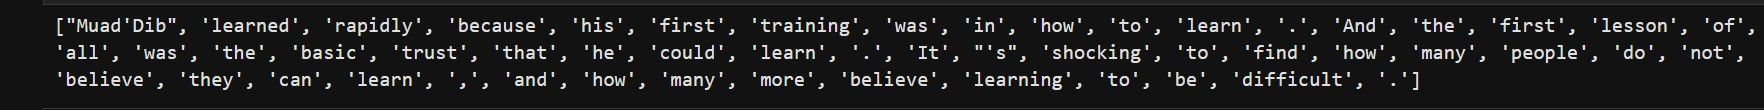

In [4]:
sentence_tokens = sent_tokenize(example_string)
sentence_tokens

["\nMuad'Dib learned rapidly because his first training was in how to learn.",
 'And the first lesson of all was the basic trust that he could learn.',
 "It's shocking to find how many people do not believe they can learn,\nand how many more believe learning to be difficult."]

I split the text into sentences using sent_tokenize.

Expected output

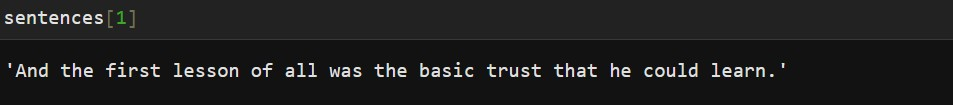

## Task 2: Filtering Stop Words

You are given a string and your task is to remove the stop words from this string using the functionality of NLTK.  Basically, you have to fetch the list containing stop words (it is available built in) and then you have to compare your input string with the list of stop words and discard the stop words to obtain the final output.

In [5]:
worf_quote = "Sir, I protest. I am not a merry man!"

In [6]:
stop_words = set(stopwords.words("english"))
worf_word_tokens = word_tokenize(worf_quote)
filtered_list = [word for word in worf_word_tokens if word.casefold() not in stop_words]
filtered_list

['Sir', ',', 'protest', '.', 'merry', 'man', '!']

I tokenized the sentence, then removed every word that is in NLTK's English stop word list.

Expected output

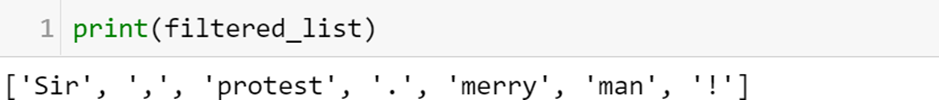

## Task 3: Stemming

Given below the following string, your task is to read the following string and convert the words to their roots.

In [7]:
string_for_stemming = "The crew of the USS Discovery discovered many discoveries. Discovering is what explorers do."


In [8]:
stemmer = PorterStemmer()
stemming_tokens = word_tokenize(string_for_stemming)
stemmed_words = [stemmer.stem(word) for word in stemming_tokens]
stemmed_words

['the',
 'crew',
 'of',
 'the',
 'uss',
 'discoveri',
 'discov',
 'mani',
 'discoveri',
 '.',
 'discov',
 'is',
 'what',
 'explor',
 'do',
 '.']

I tokenized the text and used PorterStemmer to cut each word down to its root form.

Expected output

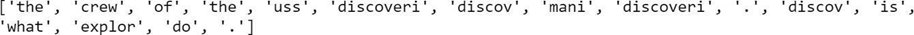

## Task 4: Tagging Part of Speech

In English, there are eight parts of speech:

| Part of speech | Role                                             | Examples                     |
|----------------|--------------------------------------------------|------------------------------|
| **Noun**       | Is a person, place, or thing                     | mountain, bagel, Poland      |
| **Pronoun**    | Replaces a noun                                  | you, she, we                 |
| **Adjective**  | Describes what a noun is like                    | efficient, windy, colorful   |
| **Verb**       | Expresses an action or state of being            | learn, is, go                |
| **Adverb**     | Modifies a verb, adjective, or another adverb    | efficiently, always, very    |
| **Preposition**| Shows how a noun/pronoun relates to another word | from, about, at              |
| **Conjunction**| Connects words or phrases                        | so, because, and             |
| **Interjection**| An exclamation                                   | yay, ow, wow                 |


Given the following string your task is to identify the relevant part of speech and mention them.

In [9]:
sagan_quote = """
If you wish to make an apple pie from scratch,
you must first invent the universe."""

In [10]:
sagan_tokens = word_tokenize(sagan_quote)
pos_tag(sagan_tokens)

[('If', 'IN'),
 ('you', 'PRP'),
 ('wish', 'VBP'),
 ('to', 'TO'),
 ('make', 'VB'),
 ('an', 'DT'),
 ('apple', 'NN'),
 ('pie', 'NN'),
 ('from', 'IN'),
 ('scratch', 'NN'),
 (',', ','),
 ('you', 'PRP'),
 ('must', 'MD'),
 ('first', 'VB'),
 ('invent', 'VB'),
 ('the', 'DT'),
 ('universe', 'NN'),
 ('.', '.')]

I tokenized the quote and used pos_tag to label each word with its part of speech.

Expected output

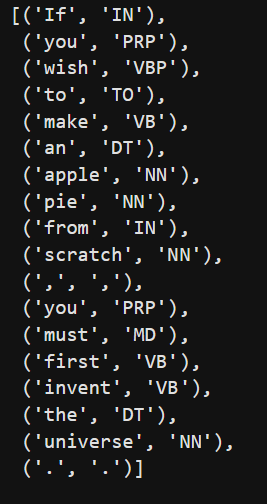

## Task 5: Lemmatizing

Now that you’re up to speed on parts of speech, you can circle back to lemmatizing. Like stemming, lemmatizing reduces words to their core meaning, but it will give you a complete English word that makes sense on its own instead of just a fragment of a word like 'discoveri'.

In [11]:
string_for_lemmatizing = "The friends of DeSoto love scarves."

In [12]:
lemmatizer = WordNetLemmatizer()
lemmatizing_tokens = word_tokenize(string_for_lemmatizing)
lemmatized_words = [lemmatizer.lemmatize(word) for word in lemmatizing_tokens]
lemmatized_words

['The', 'friend', 'of', 'DeSoto', 'love', 'scarf', '.']

I tokenized the text and used WordNetLemmatizer to reduce each word to its real dictionary base form.

Given the above string your task is to lemmatize it to obtain the following output.

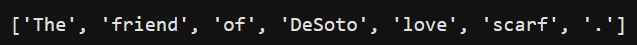

## Task 6: Chunking

Chunking is defined as the process of natural language processing used to identify parts of speech and short phrases present in a given sentence.

Note: A phrase is a word or group of words that works as a single unit to perform a grammatical function. Noun phrases are built around a noun.
Here are some examples: “A planet”
“A tilting planet”
“A swiftly tilting planet”


In [13]:
lotr_quote = "It's a dangerous business, Frodo, going out your door."

Chunking makes use of **POS (Part-of-Speech)** tags to group words and apply **chunk tags** to those groups.  
Chunks **don’t overlap**, so one instance of a word can be in only one chunk at a time.



###  Algorithmic Steps for Chunking

1. **Tokenize the given string by words.**  
First of all, you have to tokenize the input sentence into individual words.

2. **Tag words by part of speech.**  
After obtaining the list of words, the next step is to tag each word with its corresponding POS tag.

3. **Define a chunk grammar.**  
Once you have a list of word–POS tuples, define a chunk grammar to specify the structure of the chunks.  
   Example grammar:  
The grammar can be written as: `grammar = "NP: {<DT>?<JJ>*<NN>}"`.

4. **Create a chunk parser.**  
Use the defined grammar to create a chunk parser.

    chunk_parser = nltk.RegexpParser(grammar)


6. **Parse the tagged output.**  
Next step is to parse the tagged output of previous step through this parser, which will give you a tree which will contain the grouped phrases with their tagged parts of speech.



An example Tree looks like this:-

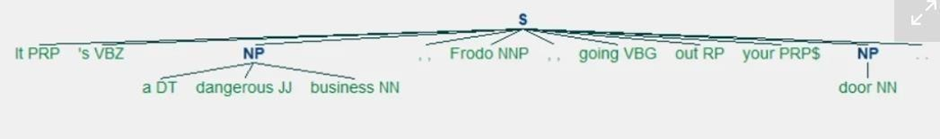

In [14]:
grammar = "NP: {<DT>?<JJ>*<NN>}"
chunk_parser = nltk.RegexpParser(grammar)

lotr_tokens = word_tokenize(lotr_quote)
lotr_pos_tags = pos_tag(lotr_tokens)

lotr_tree = chunk_parser.parse(lotr_pos_tags)
print(lotr_tree)

(S
  It/PRP
  's/VBZ
  (NP a/DT dangerous/JJ business/NN)
  ,/,
  Frodo/NNP
  ,/,
  going/VBG
  out/RP
  your/PRP$
  (NP door/NN)
  ./.)


I tagged each word with its part of speech, then used a chunk grammar to group determiner + adjective + noun words into noun phrases.

## Task 7: Combined NLP Processing

Apply all the learned NLP tasks on a given text.
Process the following text using the techniques learned in previous tasks:


In [15]:
text = "Elon Musk founded SpaceX and Tesla. He was born in South Africa and is one of the richest people in the world."

<h3 style="font-size:1.5em;">Steps:-</h3>

1. Tokenization: Split text into words and sentences.
2.	Stop Word Removal: Remove common stop words.
3.	Stemming and Lemmatization: Apply both and compare results.
4.	POS Tagging: Identify parts of speech for each word.
5.	Named Entity Recognition (NER): Identify names, places, and organizations. (optional)
6.	Chunking: Extract noun phrases.


<h3 style="font-size:1.5em;">Deliverables:</h3>


Submit your notebook with the graphs and name it as follows. Name_regnumber_lab2.ipynb Do not submit zip folders etc.


In [16]:
musk_word_tokens = word_tokenize(text)
musk_sentence_tokens = sent_tokenize(text)

musk_filtered = [w for w in musk_word_tokens if w.casefold() not in stop_words]

musk_stemmed = [stemmer.stem(w) for w in musk_word_tokens]
musk_lemmatized = [lemmatizer.lemmatize(w) for w in musk_word_tokens]

musk_pos_tags = pos_tag(musk_word_tokens)
musk_entities = ne_chunk(musk_pos_tags)

musk_grammar = "NP: {<DT>?<JJ>*<NN.*>+}"
musk_chunk_parser = RegexpParser(musk_grammar)
musk_chunks = musk_chunk_parser.parse(musk_pos_tags)

print("Words:", musk_word_tokens)
print("\nSentences:", musk_sentence_tokens)
print("\nWithout stop words:", musk_filtered)
print("\nStemmed:", musk_stemmed)
print("\nLemmatized:", musk_lemmatized)
print("\nPOS tags:", musk_pos_tags)
print("\nNamed entities:")
print(musk_entities)
print("\nNoun phrase chunks:")
print(musk_chunks)

Words: ['Elon', 'Musk', 'founded', 'SpaceX', 'and', 'Tesla', '.', 'He', 'was', 'born', 'in', 'South', 'Africa', 'and', 'is', 'one', 'of', 'the', 'richest', 'people', 'in', 'the', 'world', '.']

Sentences: ['Elon Musk founded SpaceX and Tesla.', 'He was born in South Africa and is one of the richest people in the world.']

Without stop words: ['Elon', 'Musk', 'founded', 'SpaceX', 'Tesla', '.', 'born', 'South', 'Africa', 'one', 'richest', 'people', 'world', '.']

Stemmed: ['elon', 'musk', 'found', 'spacex', 'and', 'tesla', '.', 'he', 'wa', 'born', 'in', 'south', 'africa', 'and', 'is', 'one', 'of', 'the', 'richest', 'peopl', 'in', 'the', 'world', '.']

Lemmatized: ['Elon', 'Musk', 'founded', 'SpaceX', 'and', 'Tesla', '.', 'He', 'wa', 'born', 'in', 'South', 'Africa', 'and', 'is', 'one', 'of', 'the', 'richest', 'people', 'in', 'the', 'world', '.']

POS tags: [('Elon', 'NNP'), ('Musk', 'NNP'), ('founded', 'VBD'), ('SpaceX', 'NNP'), ('and', 'CC'), ('Tesla', 'NNP'), ('.', '.'), ('He', 'PRP'), 

I ran the full pipeline on the Elon Musk text: word and sentence tokens, stop word removal, stemming, lemmatizing, POS tags, named entities, and noun phrase chunks.

## Summary

In this lab, I used NLTK to process text step by step. I split text into words and sentences, removed stop words, and reduced words to their root form with stemming and lemmatizing. I also tagged each word's part of speech, grouped words into noun phrases with chunking, and ran all of these steps together on a real example about Elon Musk.